In [17]:
import pandas as pd
orders=pd.read_csv("olist_orders_dataset.csv")
customers=pd.read_csv("olist_customers_dataset.csv")
order_items=pd.read_csv("olist_order_items_dataset.csv")
payments=pd.read_csv("olist_order_payments_dataset.csv")
reviews=pd.read_csv("olist_order_reviews_dataset.csv")
products=pd.read_csv("olist_products_dataset.csv")
sellers=pd.read_csv("olist_sellers_dataset.csv")
category_translation=pd.read_csv("product_category_name_translation.csv")

In [18]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [19]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [20]:
orders["order_purchase_timestamp"]=pd.to_datetime(orders["order_purchase_timestamp"])

In [21]:
orders["order_approved_at"]=pd.to_datetime(orders["order_approved_at"])
orders["order_delivered_carrier_date"]=pd.to_datetime(orders["order_delivered_carrier_date"])
    

In [22]:
orders["order_delivered_customer_date"]=pd.to_datetime(orders["order_delivered_customer_date"])

In [23]:
orders["order_estimated_delivery_date"]=pd.to_datetime(orders["order_estimated_delivery_date"])

In [24]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [25]:
orders["order_estimated_delivery_date"]=pd.to_datetime(orders["order_estimated_delivery_date"])

In [26]:
orders["delivery_delay"]=(orders["order_delivered_customer_date"]-orders["order_estimated_delivery_date"]).dt.days

In [27]:
orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'delivery_delay'],
      dtype='object')

In [28]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
 8   delivery_delay                 96476 non-null  float64       
dtypes: datetime64[ns](5), float64(1), object(3)
memory usage: 6.8+ MB


In [29]:
orders.describe

<bound method NDFrame.describe of                                order_id                       customer_id  \
0      e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1      53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2      47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3      949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4      ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   
...                                 ...                               ...   
99436  9c5dedf39a927c1b2549525ed64a053c  39bd1228ee8140590ac3aca26f2dfe00   
99437  63943bddc261676b46f01ca7ac2f7bd8  1fca14ff2861355f6e5f14306ff977a7   
99438  83c1379a015df1e13d02aae0204711ab  1aa71eb042121263aafbe80c1b562c9c   
99439  11c177c8e97725db2631073c19f07b62  b331b74b18dc79bcdf6532d51e1637c1   
99440  66dea50a8b16d9b4dee7af250b4be1a5  edb027a75a1449115f6b43211ae02a24   

      order_status order_purchase_timesta

In [30]:
### Although most delivered orders arrive earlier than expected, a portion of orders remain undelivered or incomplete. These cases can reduce customer trust and impact repeat purchases, indirectly affecting profitability.

In [31]:
orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'delivery_delay'],
      dtype='object')

In [32]:
order_items.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='object')

In [33]:
payments.columns

Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='object')

In [34]:
orders_items=pd.merge(orders,order_items,on='order_id',how='inner')

In [35]:
orders_items.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_delay,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,-8.0,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,06-10-2017 11:07,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,-6.0,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,30-07-2018 03:24,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,-18.0,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,13-08-2018 08:55,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,-13.0,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,23-11-2017 19:45,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,-10.0,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,19-02-2018 20:31,19.90,8.72


In [36]:
final_oip=pd.merge(orders_items,payments,on="order_id",how="inner")

In [37]:
final_oip.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_delay,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,-8.0,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,06-10-2017 11:07,29.99,8.72,1,credit_card,1,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,-8.0,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,06-10-2017 11:07,29.99,8.72,3,voucher,1,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,-8.0,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,06-10-2017 11:07,29.99,8.72,2,voucher,1,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,-6.0,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,30-07-2018 03:24,118.70,22.76,1,boleto,1,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,-18.0,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,13-08-2018 08:55,159.90,19.22,1,credit_card,3,179.12


In [38]:
final_oip["profit"]=final_oip["payment_value"]-final_oip["freight_value"]

In [39]:
final_oip.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_delay,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,payment_sequential,payment_type,payment_installments,payment_value,profit
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,-8.0,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,06-10-2017 11:07,29.99,8.72,1,credit_card,1,18.12,9.40
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,-8.0,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,06-10-2017 11:07,29.99,8.72,3,voucher,1,2.00,-6.72
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,-8.0,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,06-10-2017 11:07,29.99,8.72,2,voucher,1,18.59,9.87
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,-6.0,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,30-07-2018 03:24,118.70,22.76,1,boleto,1,141.46,118.70
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,-18.0,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,13-08-2018 08:55,159.90,19.22,1,credit_card,3,179.12,159.90


In [40]:
final_oip["profit"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 117601 entries, 0 to 117600
Series name: profit
Non-Null Count   Dtype  
--------------   -----  
117601 non-null  float64
dtypes: float64(1)
memory usage: 918.9 KB


In [41]:
final_oip["profit"].head(5)

0      9.40
1     -6.72
2      9.87
3    118.70
4    159.90
Name: profit, dtype: float64

In [42]:
### some orders are generating negative profit due to high shipping cost compared to revenue.

In [43]:
final_oip[final_oip["profit"]<0].shape   ### to find how many orders are in loss.

(2558, 20)

In [44]:
### 2558 orders are making loss

In [45]:
final_oip.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  15
order_delivered_carrier_date     1245
order_delivered_customer_date    2567
order_estimated_delivery_date       0
delivery_delay                   2567
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
payment_sequential                  0
payment_type                        0
payment_installments                0
payment_value                       0
profit                              0
dtype: int64

In [46]:
final_oip[final_oip["order_delivered_customer_date"].isnull()]["order_status"].value_counts()

order_status
shipped        1244
canceled        559
processing      375
invoiced        371
delivered         8
unavailable       7
approved          3
Name: count, dtype: int64

In [47]:
### Most missing delivery dates correspond to non-delivered orders.However,a few inconsistencies exist where delivered orders have missing delivery timestamps.

In [48]:
final_oip=final_oip[~((final_oip["order_status"]=='delivered') & (final_oip["order_delivered_customer_date"].isnull()))]

In [49]:
### Some orders are not delivered or are delayed, which reduces customer trust and satisfaction. This leads to fewer repeat purchases and affects long-term revenue. Additionally, operational costs may still be incurred on such orders, reducing profitability. Hence, delivery inefficiencies indirectly contribute to declining profit despite increasing sales.

In [50]:
final_oip[final_oip["profit"]<0].shape

(2558, 20)

In [51]:
final_oip[final_oip["profit"]<0][["payment_value","freight_value","profit"]].head()

,payment_value,freight_value,profit
1,2.00,8.72,-6.72
12,8.34,19.77,-11.43
25,5.96,16.97,-11.01
97,7.08,15.28,-8.20
120,6.83,10.96,-4.13


In [52]:
(final_oip["freight_value"]>final_oip["payment_value"]).sum()  ### seeing how many are freight_value>payment_value

np.int64(2558)

In [53]:
### All loss-making orders occur when the shipping cost exceeds the payment value, indicating that high logistics cost is the primary reason for negative profit.

In [54]:
final_oip[final_oip["profit"]<0].groupby("product_id")["profit"].sum().sort_values().head(10) ### which products are causing this loss

product_id
1aecdb5fa3add74e385f25c6c527a462   -1524.91
1d94d1e0c7fb2dcf2811e093d2ca303b    -890.34
76fab799e52e98680a1aae62daef914f    -864.29
d1c427060a0f73f6b889a5c7c61f2ac4    -654.83
ebf9bc6cd600eadd681384e3116fda85    -652.18
0554911df28fda9fd668ce5ba5949695    -483.18
e5ff2945f13a69162a72acc5170ba684    -425.18
27c0cea4dc76549f5bd124d9cad0ae3b    -401.25
4f18ca9862f511ecba98258b2194d061    -376.72
07f01b6fcacc1b187a71e5074199db2d    -362.86
Name: profit, dtype: float64

In [55]:
### some products are causing most of the loss due to high delivery cost

In [56]:
final_oip=pd.merge(final_oip,products,on='product_id',how="left")

In [57]:
final_oip[final_oip["profit"]<0].groupby("product_category_name")["profit"].sum().sort_values().head(10)

product_category_name
cama_mesa_banho          -4279.35
ferramentas_jardim       -3091.50
moveis_decoracao         -2602.47
utilidades_domesticas    -2580.99
informatica_acessorios   -2057.28
esporte_lazer            -1456.99
beleza_saude             -1286.69
moveis_escritorio        -1098.48
brinquedos               -1073.18
telefonia                -1001.83
Name: profit, dtype: float64

In [58]:
final_oip.to_csv("final_data.csv",index=False)

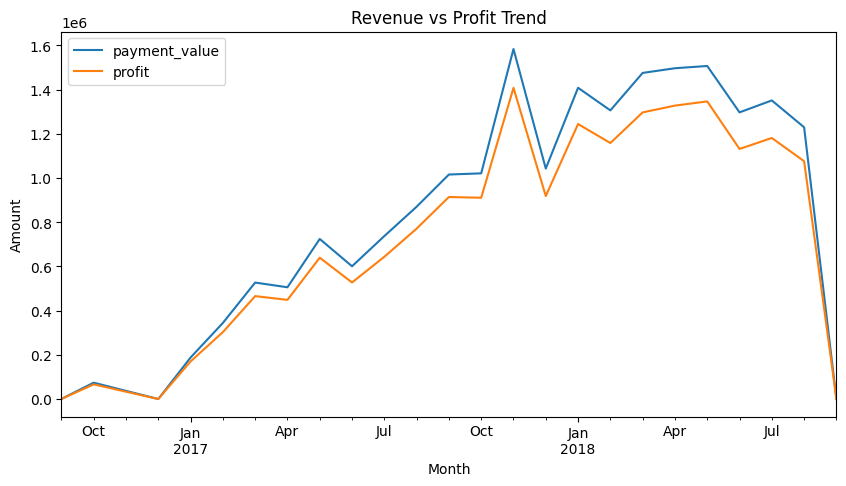

In [60]:
import matplotlib.pyplot as plt

monthly = final_oip.groupby(final_oip['order_purchase_timestamp'].dt.to_period('M'))[['payment_value','profit']].sum()

monthly.plot(figsize=(10,5))
plt.title("Revenue vs Profit Trend")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.show()

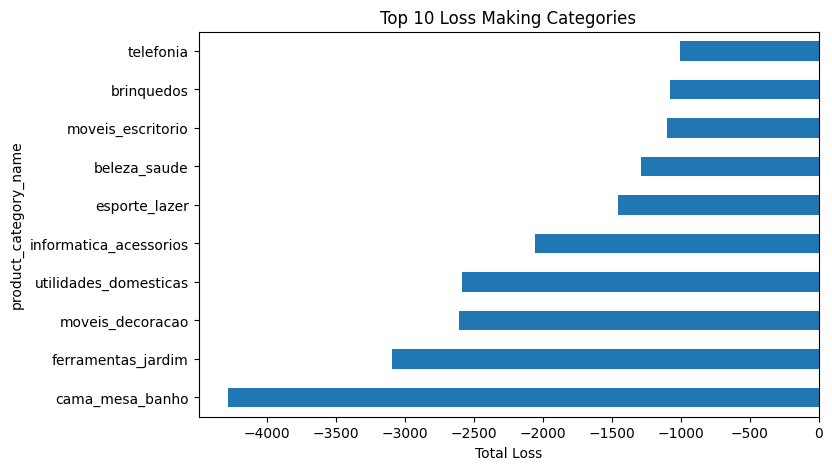

In [62]:
loss_cat = final_oip[final_oip['profit'] < 0] \
    .groupby('product_category_name')['profit'] \
    .sum() \
    .sort_values()

loss_cat.head(10).plot(kind='barh', figsize=(8,5))
plt.title("Top 10 Loss Making Categories")
plt.xlabel("Total Loss")
plt.show()

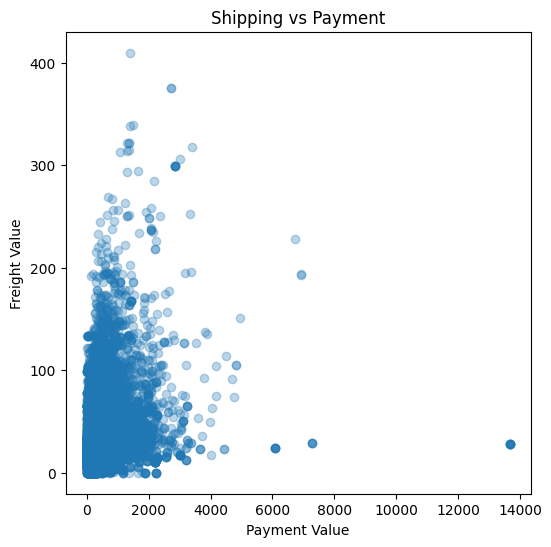

In [65]:
plt.figure(figsize=(6,6))
plt.scatter(final_oip['payment_value'], final_oip['freight_value'], alpha=0.3)
plt.xlabel("Payment Value")
plt.ylabel("Freight Value")
plt.title("Shipping vs Payment")
plt.show()

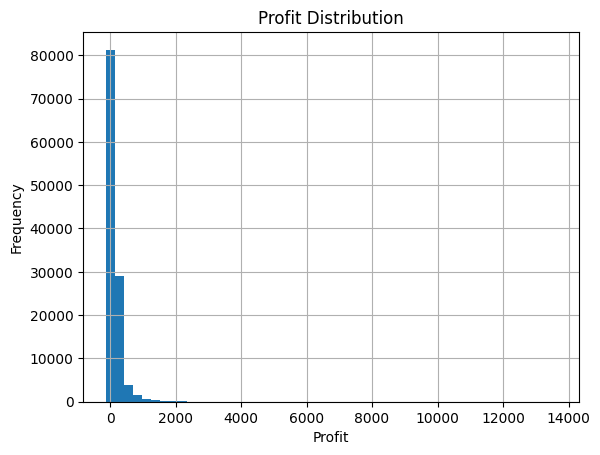

In [66]:
final_oip['profit'].hist(bins=50)
plt.title("Profit Distribution")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.show()

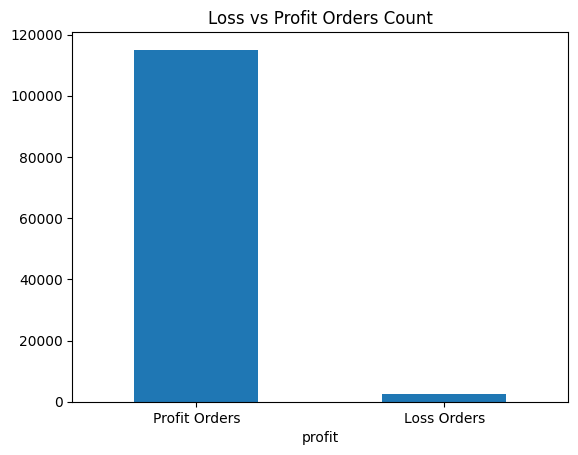

In [68]:
loss_count = (final_oip['profit'] < 0).value_counts()

loss_count.plot(kind='bar')
plt.title("Loss vs Profit Orders Count")
plt.xticks([0,1], ['Profit Orders','Loss Orders'], rotation=0)
plt.show()